In [1]:
import pathlib
import collections
import itertools
import glob, os, multiprocessing

import joblib


import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import scipy.signal
import scipy.interpolate

import gsd
import gsd.hoomd

import freud
import freud.box

import cooltools
import cooltools.sandbox
#import cooltools.lib.plotting

import pairtools
import pairtools.lib.scaling
# from pairtools.lib.scaling import norm_scaling, norm_scaling_factor


import bioframe

import polykit
import polykit.io
import polykit.io.cache
import polykit.io.fetch_hoomd

In [2]:

SIGMA_SMOOTH_LOG10 = 0.03

def norm_scaling_factor(bins, cfreqs, norm_at_window):
    lo,hi = np.searchsorted(bins, norm_at_window)
    return cfreqs[lo:hi+1].mean()


def norm_scaling(bins, cfreqs, norm_at_window, log_input=False):
    norm = norm_scaling_factor(bins, cfreqs, norm_at_window)
    if log_input:
        return cfreqs - norm
    else:
        return cfreqs / norm


def unity_norm_scaling(values, bin_mids, bin_lens, norm_range=(1e4, 1e9)):
    if norm_range is None:
        norm_values = values / np.sum(1. * (bin_lens * values)[np.isfinite(values)])
    else:
        norm_values = values / np.sum(1. * (bin_lens * values)[
            np.isfinite(values)
            & (bin_mids > norm_range[0])
            & (bin_mids < norm_range[1])])
    return norm_values



In [3]:

def smooth_scaling(sc, sigma_smooth_log10, preset='pairs'):
    if preset == 'pairs':
        cols = dict(
                dist='dist',
                n_pixels='n_bp2',
                n_contacts='n_pairs',
                output_prefix='contact_freq',)
    elif preset == 'sim':
        cols=dict(
            dist='dist',
            n_pixels='n_particle_pairs',
            n_contacts='n_contacts',
            output_prefix='contact_freq'
        )
    else:
        raise ValueError('Unknown preset')



    sc_smooth = cooltools.api.expected.genomewide_smooth_cvd(
        sc,
        sigma_log10=sigma_smooth_log10,
        cols=cols
    )   

    return sc_smooth



def get_Ps_peaks(sc, sigma_smooth_log10=SIGMA_SMOOTH_LOG10, sc_type='sim', contact_freq_col='contact_freq'):

    sc_smooth = smooth_scaling(sc, sigma_smooth_log10, preset=sc_type)

    xs, ys = sc.dist.values, np.log10(sc_smooth[contact_freq_col].values)
    mask = xs > 1e4
    xs, ys = xs[mask], ys[mask]

    peaks = scipy.signal.find_peaks(
        ys, 
        prominence=0.001,
        )
    return xs[peaks[0]]


def plot_scaling(dists, cf, norm_at=(3e3,4e3), reset=False, trans_cf=None, fig_kw=dict(figsize=(5,10)), line_kw={}):

    if reset or len(plt.gcf().get_axes()) == 0:
        fig, _ = plt.subplot_mosaic('A\nA\nA\nB', **fig_kw)
    else:
        fig = plt.gcf()


    ax = [a for a in fig.axes if a._label=='A'][0]

    norm = norm_scaling_factor(
        dists,
        cf,
        norm_at)

    line = ax.loglog(
        dists,
        cf/norm,
        **line_kw,
        )
    
    if trans_cf:
        ax.axhline(trans_cf/norm, ls='--', c=line[0].get_color())

    ax.set(
        aspect = 1.0,
        xlim = (1e3,1e8),
        ylim = (2e-5,2e0),
        xlabel = 'separation, kb',
        ylabel = 'contact frequency',
    )
    
    ax.grid(True)
    ax.xaxis.set_major_locator(matplotlib.ticker.LogLocator(base=10.0,numticks=20))


    ax = [a for a in fig.axes if a._label=='B'][0]

    ax.semilogx(
        np.sqrt(dists[1:] * dists[:-1]),
        np.diff(np.log10(cf)) / np.diff(np.log10(dists)),
        **line_kw,

    )
    
    ax.set(
        aspect = 1.0,
        xlim = (1e3,1e8),
        ylim = (-2,0),
        xlabel = 'separation, kb',
        ylabel = 'contact frequency',
    )
        
    ax.grid(True)
    ax.xaxis.set_major_locator(matplotlib.ticker.LogLocator(base=10.0,numticks=20))
    
    return fig, ([a for a in fig.axes if a._label=='A'][0], [a for a in fig.axes if a._label=='B'][0])



def plot_sim_scalings(
    sc,
    norm_at=(3e3,4e3),
    bins_decade=100,
    sigma_smooth_log10=0.03,
    line_kw=dict(label='')
):

    line_kw = dict(line_kw)
    
    bp_per_particle = 200

    if sigma_smooth_log10:
        sc = smooth_scaling(sc, sigma_smooth_log10, preset='sim')
        sc = (sc.dist.values*bp_per_particle, sc['contact_freq.smoothed'].values)

    else:
        sc = (sc.dist.values*bp_per_particle, sc.contact_freq.values)

    if line_kw.get('label', None):
        line_kw['label'] = eval(f"f'''{line_kw['label']}'''")

    fig, axs = plot_scaling(
        sc[0], 
        sc[1], 
        norm_at=norm_at, 
        line_kw=line_kw)

    axs[0].legend(loc=(1.1,0.2))
    return fig, axs


def folder2params(folder):
    params = pathlib.Path(folder).name.split('-')
    params = dict(s.split('_') for s in params)
    params = {k: eval(v) if v.lstrip('-').replace('.','',1).isdigit() else None for k, v in params.items()}
    return params


def key_f(folder, group_sims_by):
    params = folder2params(folder)
    if issubclass(type(group_sims_by), collections.abc.Iterable):
        return tuple(params[k] for k in group_sims_by)
    elif not group_sims_by:
        return tuple(params.values())
    else:
        raise ValueError('agg_params must be iterable or None/False.')

    
def scalar_to_list(scalar):
    if isinstance(scalar, collections.abc.Iterable):
        return scalar
    else:
        return [scalar]


def cached_contact_vs_dist_parallel(
    folders,
    frame_idxs,
    sigmas,
    **kwargs
    ):

    def load_scaling(folder, frame_idx, sigma, **kwargs):
        try:
            folder = pathlib.Path(folder) if pathlib.Path(folder).is_dir() else pathlib.Path(folder).parent
            sc = polykit.io.cache.cached_contact_vs_dist(
                folder,
                fetch_func=polykit.io.fetch_hoomd.fetch_frame,
                get_abs_frame_idx=polykit.io.fetch_hoomd.get_abs_frame_idx,
                frame_idx=frame_idx,
                random_sigma=sigma,
                **kwargs).assign(
                    folder=folder.name,
                    t=polykit.io.fetch_hoomd.get_frame_nsteps(folder, frame_idx),                
                    sigma=sigma,
                    **folder2params(folder))
            return sc
        except Exception as e:
            print(e)
            return None

    args = [
            ((folder, frame_idx, sigma), kwargs)
            for frame_idx in scalar_to_list(frame_idxs)
            for sigma in scalar_to_list(sigmas)
            for folder in folders
        ]

    out_scs = joblib.Parallel(
        n_jobs=-1,
        verbose=10
    )(
        joblib.delayed(load_scaling)(*arg, **kwargs) for arg, kwargs in args
    )         

    return out_scs

[PosixPath('src/mitotic_chromosome_models_v2/best_models/SMC3-CAPH2/N_500000-InLoop_100.0-OutLoop_0.0-InSpacing_2-OutSpacing_6-IOOffset_5-LoopBondLen_1.0-RootSpacers_1-ConfType_Periodic-LinDens_25.0-BoxPP_1.37-RepA_3.0-G_1.0-DT_0.05-R_0'),
 PosixPath('src/mitotic_chromosome_models_v2/best_models/SMC3-CAPH2/N_500000-InLoop_100.0-OutLoop_0.0-InSpacing_2-OutSpacing_6-IOOffset_5-LoopBondLen_1.0-RootSpacers_1-ConfType_Periodic-LinDens_25.0-BoxPP_1.37-RepA_3.0-G_1.0-DT_0.05-R_3'),
 PosixPath('src/mitotic_chromosome_models_v2/best_models/SMC3-CAPH2/N_500000-InLoop_100.0-OutLoop_0.0-InSpacing_2-OutSpacing_6-IOOffset_5-LoopBondLen_1.0-RootSpacers_1-ConfType_Periodic-LinDens_25.0-BoxPP_1.37-RepA_3.0-G_1.0-DT_0.05-R_4'),
 PosixPath('src/mitotic_chromosome_models_v2/best_models/SMC3-CAPH2/N_500000-InLoop_100.0-OutLoop_0.0-InSpacing_2-OutSpacing_6-IOOffset_5-LoopBondLen_1.0-RootSpacers_1-ConfType_Periodic-LinDens_25.0-BoxPP_1.37-RepA_3.0-G_1.0-DT_0.05-R_5')]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done   2 out of   4 | elapsed:    8.7s remaining:    8.7s
[Parallel(n_jobs=-1)]: Done   4 out of   4 | elapsed:    9.0s finished


4


/tmp/ipykernel_74068/17206759.py:85: RuntimeWarning: divide by zero encountered in log10
  np.diff(np.log10(cf)) / np.diff(np.log10(dists)),
/users/anton.goloborodko/.conda/envs/main3/lib/python3.11/site-packages/numpy/lib/function_base.py:1452: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/tmp/ipykernel_74068/17206759.py:34: RuntimeWarning: divide by zero encountered in log10
  xs, ys = sc.dist.values, np.log10(sc_smooth[contact_freq_col].values)


'InLoop=100.0, InSpacing=2, sigma=4.8'

array([], dtype=float64)

<Figure size 640x480 with 0 Axes>

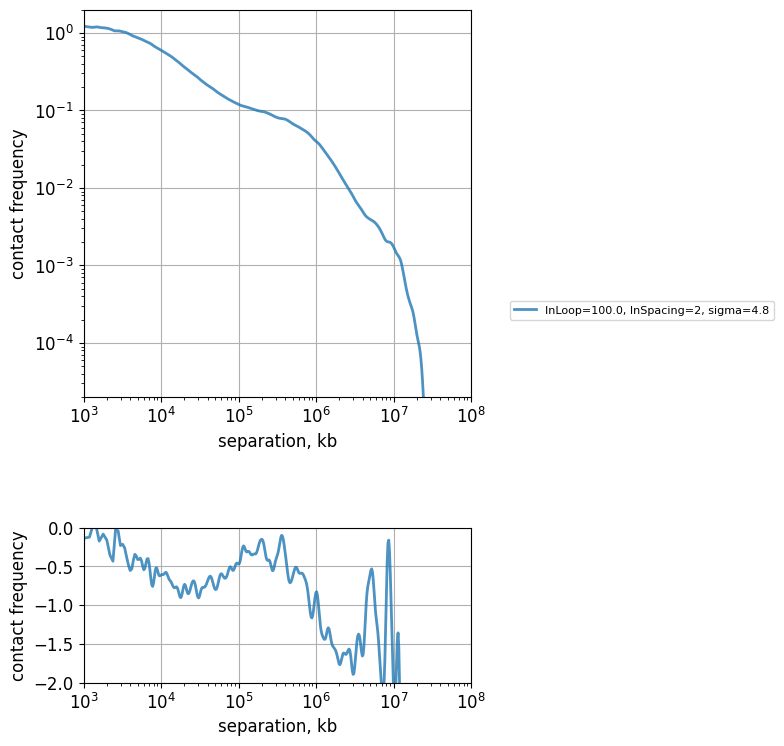

In [ ]:

SIGMA = 4.8 # overlapping



NORM_AT = (3e3,4e3)
SIGMA_SMOOTH_LOG10 = 0.03


GROUP_SIMS_BY = ['InLoop', 'InSpacing'] 


GROUP_SIMS_BY += ['sigma']
# GROUP_SIMS_BY += ['t']
# GROUP_SIMS_BY += ['R']

FRAME_IDX = [-1]

DFOLDER_MASKS = [
    './src/mitotic_chromosome_models_v2/best_models/SMC3-CAPH2/*',
]

DFOLDERS = sorted([
    folder
    for mask in DFOLDER_MASKS
    for folder in pathlib.Path('.').glob(mask)
])

display(DFOLDERS)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# sc_exp_smooth = smooth_scaling(sc_exp_agg, sigma_smooth_log10=SIGMA_SMOOTH_LOG10, preset='pairs')

# fig, axs = plot_scaling(
#     sc_exp_smooth.dist.values,
#     sc_exp_smooth['contact_freq.smoothed'].values,
#     norm_at=NORM_AT,
#     reset=True,
#     #trans_cf=trans_cf*2,
#     line_kw=dict(lw=2, alpha=0.8),
# )

scs = cached_contact_vs_dist_parallel(
    DFOLDERS,
    FRAME_IDX,
    SIGMA,
    contact_radius=1.1,
    bins_decade=100,
    # random_reps=100
    )

print(len(scs))

scs_agg = (
    pd.concat(scs)
    .groupby(['dist', 'min_dist', 'max_dist'] + GROUP_SIMS_BY)
    .agg(dict(n_contacts=np.sum,
            n_particle_pairs=np.sum))
    .reset_index()
    .assign(contact_freq=lambda df: df.n_contacts / df.n_particle_pairs)
)

if GROUP_SIMS_BY:
    for label, sc in scs_agg.groupby(GROUP_SIMS_BY):
        if issubclass(type(label), (list, tuple)):
            label = ', '.join([f'{k}={v}' for k,v in zip(GROUP_SIMS_BY, label)])
        
        plot_sim_scalings(
            sc, 
            norm_at=NORM_AT,
            sigma_smooth_log10=SIGMA_SMOOTH_LOG10,
            line_kw=dict(label=label, lw=2, alpha=0.8)
        )
        display(
            label,
            get_Ps_peaks(sc, sigma_smooth_log10=SIGMA_SMOOTH_LOG10, sc_type='sim', contact_freq_col='contact_freq.smoothed') * 200
        )
else:
    plot_sim_scalings(
        sc, 
        norm_at=NORM_AT,
        sigma_smooth_log10=SIGMA_SMOOTH_LOG10,
        line_kw=dict(lw=2, alpha=0.8)
    ) 
    display(
        label,
        get_Ps_peaks(
            sc, 
            sigma_smooth_log10=SIGMA_SMOOTH_LOG10, 
            sc_type='sim', 
            contact_freq_col='contact_freq.smoothed') * 200
    )
    
#